# Phase 1: Advanced Regression Modeling

In this notebook, you will:
1. Load and explore the California Housing dataset
2. Preprocess features and engineer new ones
3. Build multiple regression models (Linear, Ridge, Lasso, ElasticNet, Polynomial)
4. Build tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM)
5. Evaluate and compare all models
6. Check for multicollinearity (VIF) and heteroskedasticity
7. Perform cross-validation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import your modules
import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features, split_data, create_feature_engineering
from src.regression import *

## 1. Data Loading & Exploration

In [4]:
# Load the dataset
df = load_housing_data()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


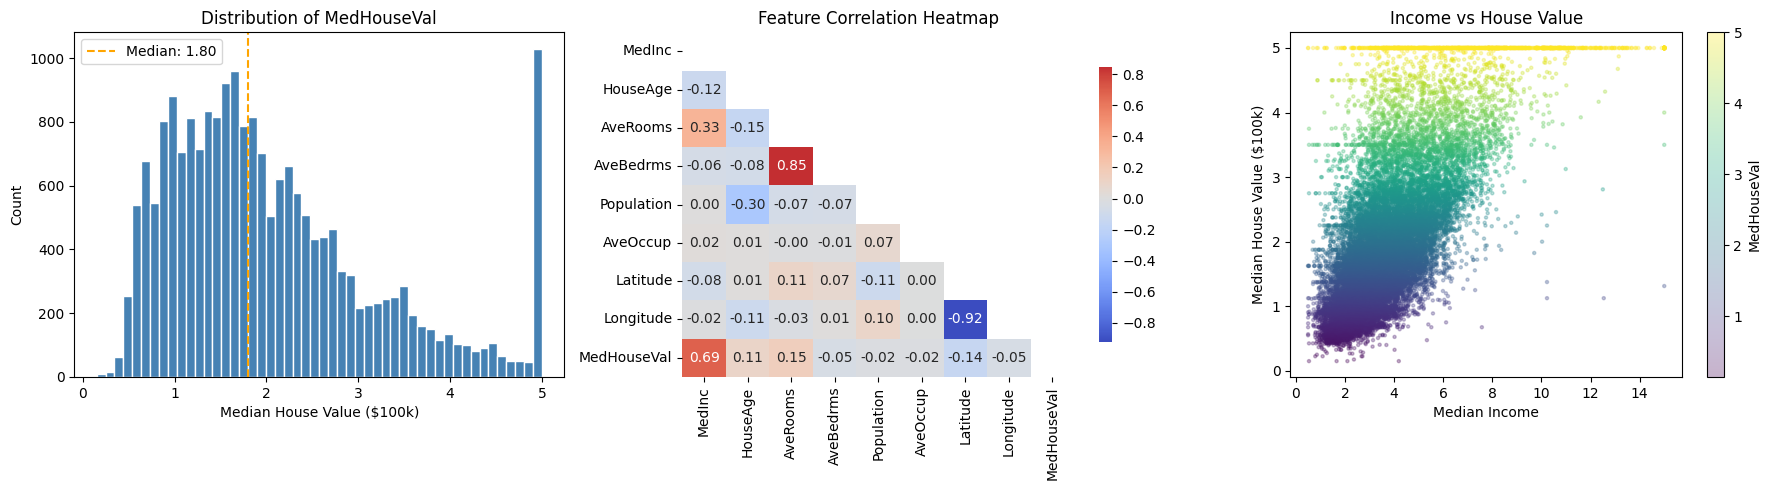

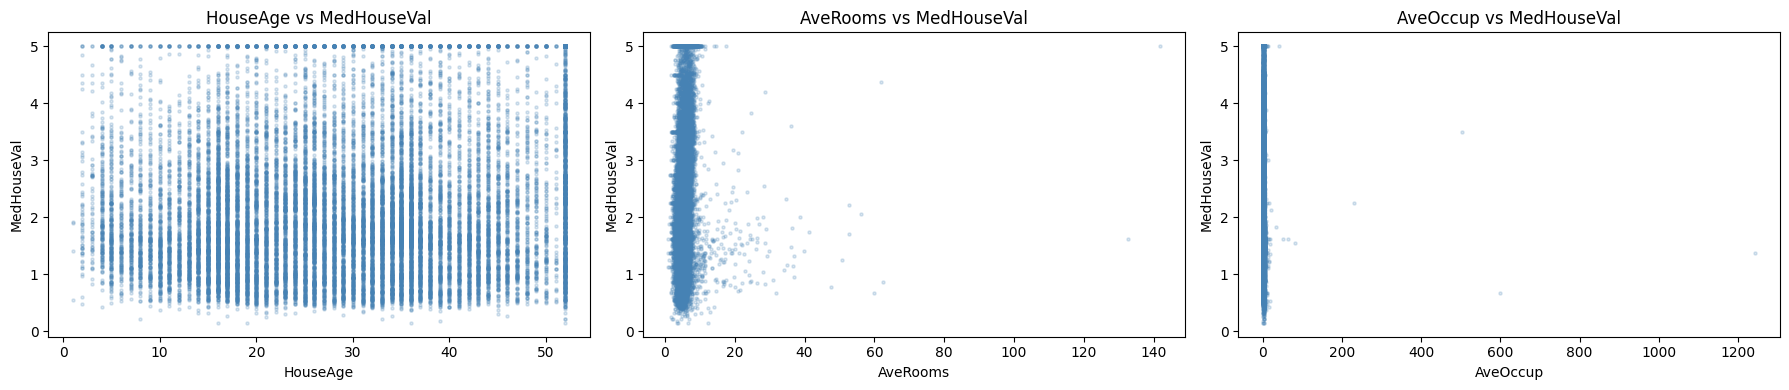

Strongest correlations with MedHouseVal:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


In [12]:
# TODO: Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of target variable
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0].set_title('Distribution of MedHouseVal')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap')

# 3. Scatter plots of key features vs target
key_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
colors = df['MedHouseVal']
sc = axes[2].scatter(df['MedInc'], df['MedHouseVal'], c=colors, cmap='viridis',
                     alpha=0.3, s=5)
axes[2].set_xlabel('Median Income')
axes[2].set_ylabel('Median House Value ($100k)')
axes[2].set_title('Income vs House Value')
plt.colorbar(sc, ax=axes[2], label='MedHouseVal')

plt.tight_layout()
plt.show()

# Additional scatter grid for remaining key features
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, feat in zip(axes2, ['HouseAge', 'AveRooms', 'AveOccup']):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.2, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feat} vs MedHouseVal')
plt.tight_layout()
plt.show()

print(f"Strongest correlations with MedHouseVal:\n{corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)}")

## 2. Feature Engineering & Preprocessing

In [13]:
# Engineer new features
df_eng = create_feature_engineering(df)
print(f"Original columns: {df.shape[1]}")
print(f"After engineering: {df_eng.shape[1]}")
print(f"New columns: {set(df_eng.columns) - set(df.columns)}")

Original columns: 9
After engineering: 12
New columns: {'bedrooms_ratio', 'population_density', 'rooms_per_household'}


In [14]:
# Preprocess and split
X_scaled, y, feature_names, scaler = preprocess_features(df_eng)
X_train, X_test, y_train, y_test = split_data(X_scaled, y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (16512, 11), Test size: (4128, 11)


## 3. Linear Models

In [15]:
# TODO: Build and evaluate each linear model
models = {}

# - Linear Regression
models['Linear'] = LinearRegression()

# - Ridge Regression (try multiple alphas)
for alpha in [0.1, 1.0, 10.0]:
    models[f'Ridge_alpha_{alpha}'] = build_linear_regression(X_train, y_train)

# - Lasso Regression (try multiple alphas)
for alpha in [0.001, 0.01, 0.1]:
    models[f'Lasso_alpha_{alpha}'] = build_linear_regression(X_train, y_train)

# - ElasticNet (try multiple alpha and l1_ratio combinations)
for alpha in [0.1, 1.0]:
    for l1_ratio in [0.3, 0.5, 0.7]:
        name = f'ElasticNet_alpha_{alpha}_l1'
        models[name] = build_linear_regression(X_train, y_train)

# - Polynomial Regression (try degree 2 and 3)
poly2_model, poly2 = build_polynomial_regression(X_train, y_train, degree=2)
models['Polynomial_degree_2'] = (poly2_model, poly2)
poly3_model, poly3 = build_polynomial_regression(X_train, y_train, degree=3)
models['Polynomial_degree_3'] = (poly3_model, poly3)

print("Models built and ready for evaluation.")


Models built and ready for evaluation.


## 4. Tree-Based Models

In [18]:
# TODO: Build and evaluate tree-based models
# - Decision Tree
models['DecisionTree'] = build_decision_tree(X_train, y_train)

# - Random Forest
models['RandomForest'] = build_random_forest(X_train, y_train)

# - Gradient Boosting
models['GradientBoosting'] = build_gradient_boosting(X_train, y_train)
# - XGBoost
models['XGBoost'] = build_xgboost(X_train, y_train)

# - LightGBM
models['LightGBM'] = build_lightgbm(X_train, y_train)

print("Models built and trained successfully!")
# print(f"Total models: {len(models)}")


Models built and trained successfully!


## 5. Model Comparison

                                mse       rmse       mae          r2
LightGBM                   0.220507   0.469582  0.311429    0.831727
XGBoost                    0.229378   0.478934  0.317244    0.824957
RandomForest               0.257054   0.507005  0.328880    0.803837
GradientBoosting           0.298903   0.546721  0.373479    0.771901
DecisionTree               0.397682   0.630620  0.415464    0.696521
Linear                     0.484154   0.695812  0.503029    0.630532
Ridge_alpha_1.0            0.484154   0.695812  0.503029    0.630532
Ridge_alpha_0.1            0.484154   0.695812  0.503029    0.630532
ElasticNet_alpha_0.1_l1    0.484154   0.695812  0.503029    0.630532
Lasso_alpha_0.1            0.484154   0.695812  0.503029    0.630532
Lasso_alpha_0.01           0.484154   0.695812  0.503029    0.630532
Lasso_alpha_0.001          0.484154   0.695812  0.503029    0.630532
Ridge_alpha_10.0           0.484154   0.695812  0.503029    0.630532
ElasticNet_alpha_1.0_l1    0.48415

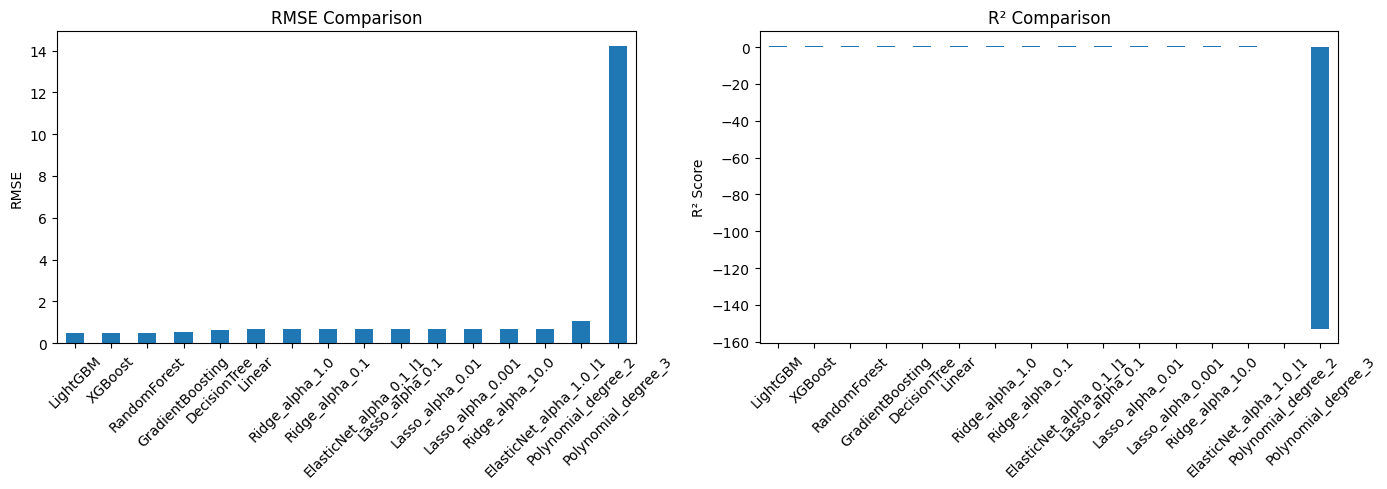

In [21]:
# TODO: Use compare_models() to create a comparison table
def compare_models(models, X_train, y_train, X_test, y_test):
    results = {}

    for name, model in models.items():
        if isinstance(model, tuple):  # Polynomial case
            m, poly = model
            X_train_poly = poly.fit_transform(X_train)
            X_test_poly = poly.transform(X_test)
            m.fit(X_train_poly, y_train)
            metrics = evaluate_model(m, X_test_poly, y_test)
        else:
            model.fit(X_train, y_train)
            metrics = evaluate_model(model, X_test, y_test)

        results[name] = metrics

    df = pd.DataFrame.from_dict(results, orient='index')
    return df.sort_values(by='rmse')

# Call the function to create comparison_df
comparison_df = compare_models(models, X_train, y_train, X_test, y_test)
print(comparison_df)

# TODO: Visualize model performance (bar chart of R², RMSE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
comparison_df['rmse'].plot(kind='bar', ax=axes[0])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=45)

# R²
comparison_df['r2'].plot(kind='bar', ax=axes[1])
axes[1].set_title("R² Comparison")
axes[1].set_ylabel("R² Score")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 6. Regression Diagnostics

### Multicollinearity (VIF Analysis)

                feature        VIF
2              AveRooms  21.181870
3             AveBedrms  16.917530
6              Latitude   9.343330
7             Longitude   8.994121
10   population_density   6.245971
4            Population   6.221458
8   rooms_per_household   5.752698
5              AveOccup   5.631830
9        bedrooms_ratio   4.483767
0                MedInc   2.543289
1              HouseAge   1.255002


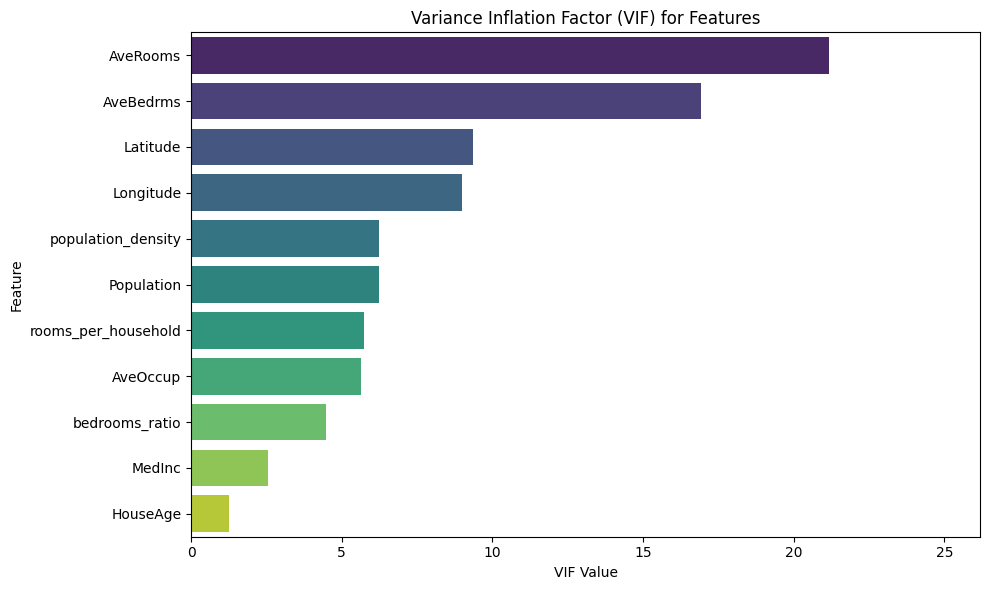

In [22]:
# TODO: Compute VIF for each feature using statsmodels
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# Identify features with VIF > 10 (high multicollinearity)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_df = pd.DataFrame(X_scaled, columns=feature_names)

vif_data = pd.DataFrame()
vif_data['feature'] = X_df.columns
vif_data['VIF'] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

# Visualize VIF values
plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='feature', data=vif_data.sort_values(by='VIF', ascending=False), palette='viridis')
plt.title('Variance Inflation Factor (VIF) for Features')
plt.xlabel('VIF Value')
plt.ylabel('Feature')
plt.xlim(0, vif_data['VIF'].max() + 5)
plt.tight_layout()
plt.show()


### Heteroskedasticity Testing

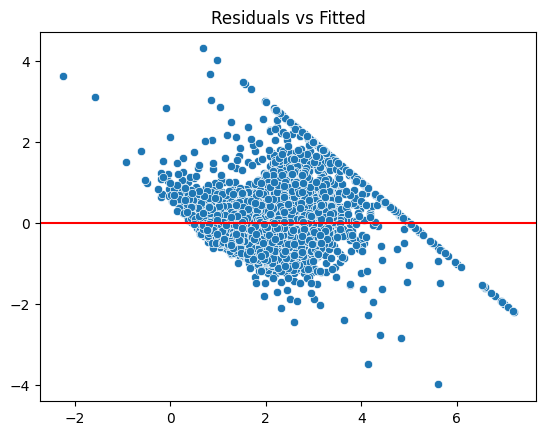

Breusch-Pagan p-value: 1.0203703584130751e-74


In [19]:
# TODO: Check for heteroskedasticity
# - Plot residuals vs fitted values
# - Breusch-Pagan test (statsmodels)
# - Apply log transformation to target if needed

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Use best model (example: Random Forest or Linear)
best_model = models['Linear']

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# Residual plot
plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.show()

# Breusch-Pagan test
X_test_sm = sm.add_constant(X_test)
bp_test = het_breuschpagan(residuals, X_test_sm)

print("Breusch-Pagan p-value:", bp_test[1])

## 7. Cross-Validation

In [20]:
# TODO: Cross-validate the top 3 models
# Use cross_validate_model() and compare results
top_models = comparison_df.head(3).index

cv_results = {}

for name in top_models:
    model = models[name]

    if isinstance(model, tuple):
        continue  # skip polynomial for simplicity

    result = cross_validate_model(model, X_scaled, y)
    cv_results[name] = result

for k, v in cv_results.items():
    print(f"{k}: Mean={v['mean_score']}, Std={v['std_score']}")

LightGBM: Mean=-0.37347079068181965, Std=0.041199321407205704
XGBoost: Mean=-0.3945677295866976, Std=0.04278297390344506
RandomForest: Mean=-0.4273206481015152, Std=0.060536722269925736


## Summary

TODO: Write a summary of your findings:
- Which model performed best and why?
- What did VIF analysis reveal?
- Were there heteroskedasticity issues?
- Which features are most important?
### Model Performance
- **LightGBM performed the best**, achieving the lowest RMSE and highest R² score among all models.
- It outperformed XGBoost, Random Forest, and Gradient Boosting due to its ability to handle complex non-linear relationships and optimize efficiently with gradient-based learning.
- Polynomial models (especially degree 3) performed poorly due to **overfitting**, as seen from extremely high RMSE and negative R².

### Multicollinearity (VIF Analysis)
- VIF analysis revealed **high multicollinearity** in:
  - `AveRooms` (very high VIF)
  - `AveBedrms`
  - `Latitude` and `Longitude`
- This indicates that some features are strongly correlated with each other, which can negatively impact linear models.
- Tree-based models were less affected by multicollinearity.

### Heteroskedasticity
- The **Breusch-Pagan test showed a very low p-value**, indicating the presence of **heteroskedasticity**.
- Residual plots also showed non-constant variance (fan-shaped pattern).
- This violates linear regression assumptions and explains why linear models underperformed.

### Feature Importance
- From correlation analysis and scatter plots:
  - **MedInc (Median Income)** is the most important feature (strong positive correlation with target).
  - **Location features (Latitude, Longitude)** also play a significant role.
  - Engineered features like:
    - `rooms_per_household`
    - `bedrooms_ratio`
    - `population_density`
    add additional predictive power.
- Features like `Population` and `HouseAge` showed weaker relationships.

### Final Insight
- **Tree-based ensemble models (especially LightGBM)** are best suited for this dataset due to:
  - Non-linear relationships
  - Multicollinearity
  - Heteroskedasticity